## 00.a Imports

In [110]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import EllipseModel, ransac
from scipy.optimize import curve_fit
from sklearn.mixture import GaussianMixture

# Load Mnist dataset
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

## 00.b Import dataset

In [ ]:
# Load the dataset
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# Display the shape of the dataset
print("Train images shape:", train_images.shape)
print("Train labels shape:", train_labels.shape)
print("Test images shape:", test_images.shape)
print("Test labels shape:", test_labels.shape)


## 01.a Use **RANSAC** to find 
- lines, (in the end not the main objective)
- **circles**,
- elipses (finds none)

In [87]:
def ransac_multi_line(points, threshold=5, iterations=1000, max_lines=2):
    detected_lines = []

    for _ in range(max_lines):  # Try to detect multiple lines
        max_inliers = 0
        best_line = None

        for _ in range(iterations):
            sample = points[np.random.choice(points.shape[0], 2, replace=False)]
            x1, y1 = sample[0]
            x2, y2 = sample[1]

            if np.abs(x1 - x2) < 1e-1:  # Handle vertical lines
                A, B, C = 1, 0, -x1  # Equation: x - x1 = 0 -> 1*x + 0*y - x1 = 0
                distances = np.abs(points[:, 0] - x1)  # Use only the x-distance for vertical lines
            else:
                A = y2 - y1
                B = x1 - x2
                C = x2 * y1 - x1 * y2
                distances = np.abs(A * points[:, 0] + B * points[:, 1] + C) / np.sqrt(A**2 + B**2)

            inliers = points[distances < threshold]

            if len(inliers) > max_inliers:
                max_inliers = len(inliers)
                best_line = (A, B, C)

        if best_line is None:
            break  # Stop if no valid line is found

        detected_lines.append(best_line)

        # Remove inliers to avoid detecting the same line
        mask = np.abs(A * points[:, 0] + B * points[:, 1] + C) / np.sqrt(A**2 + B**2) >= threshold
        points = points[mask]

        if len(points) < 2:  # Stop if too few points remain
            break

    return detected_lines

def ransac_multi_circle(points, threshold=5, iterations=1000, max_circles=2, min_distance=1):
    detected_circles = []
    
    for _ in range(max_circles):  # Try to detect multiple circles
        max_inliers = 0
        best_circle = None

        for _ in range(iterations):
            # Randomly pick 3 points
            sample = points[np.random.choice(points.shape[0], 3, replace=False)]
            
            # Solve for circle parameters (center and radius)
            A = np.array([
                [sample[0][0], sample[0][1], 1],
                [sample[1][0], sample[1][1], 1],
                [sample[2][0], sample[2][1], 1]
            ])
            
            B = np.array([
                -(sample[0][0]**2 + sample[0][1]**2),
                -(sample[1][0]**2 + sample[1][1]**2),
                -(sample[2][0]**2 + sample[2][1]**2)
            ])
            
            try:
                sol = np.linalg.solve(A, B)
            except np.linalg.LinAlgError:
                continue  # Skip if singular matrix

            x_c, y_c = -0.5 * sol[:2]
            r = np.sqrt((sol[0]**2 + sol[1]**2) / 4 - sol[2])
            
            if r <= 0 or np.isnan(r):  # Ignore invalid circles
                continue

            # Compute inliers
            distances = np.abs(np.sqrt((points[:, 0] - x_c)**2 + (points[:, 1] - y_c)**2) - r)
            inliers = points[distances < threshold]

            if len(inliers) > max_inliers:
                max_inliers = len(inliers)
                best_circle = (x_c, y_c, r)

        if best_circle is None:
            break  # Stop if no valid circle is found

        # Ensure circles are not too close to each other
        x_c, y_c, r = best_circle
        if any(np.linalg.norm(np.array([x_c, y_c]) - np.array([xc, yc])) < min_distance for xc, yc, _ in detected_circles):
            continue  # Skip if too close to existing circle

        # if len(inliers) > 10:
        detected_circles.append(best_circle)

        # Remove inliers to prevent detecting the same circle
        # mask = np.abs(np.sqrt((points[:, 0] - x_c)**2 + (points[:, 1] - y_c)**2) - r) >= threshold
        # points = points[mask]

        if len(points) < 3:  # Stop if too few points remain
            break

    return detected_circles


def ransac_multi_ellipse(points, threshold=5, iterations=1000, max_ellipses=3, min_distance=10):
    detected_ellipses = []
    
    for _ in range(max_ellipses):  # Try to detect multiple ellipses
        max_inliers = 0
        best_ellipse = None

        for _ in range(iterations):
            # Randomly select 5 points
            sample = points[np.random.choice(points.shape[0], 5, replace=False)]

            # Solve for ellipse parameters using least squares
            X = np.column_stack((
                sample[:, 0]**2, 
                sample[:, 0] * sample[:, 1],
                sample[:, 1]**2, 
                sample[:, 0], 
                sample[:, 1],
                np.ones(sample.shape[0])
            ))
            
            try:
                U, S, Vt = np.linalg.svd(X)
                coeffs = Vt[-1, :]
            except np.linalg.LinAlgError:
                continue

            A, B, C, D, E, F = coeffs

            # Compute center of ellipse
            denom = 4*A*C - B**2
            if np.abs(denom) < 1e-6:  # Avoid degenerate cases
                continue

            x0 = (B*E - 2*C*D) / denom
            y0 = (B*D - 2*A*E) / denom

            # Compute ellipse axes lengths
            a_val = 2 * (A*F + C*F + E**2 - 4*B*F - D**2 - C*E)
            b_val = 2 * (A*F + C*F + E**2 - 4*B*F - D**2 - A*D)
            
            if a_val <= 0 or b_val <= 0:
                continue

            a = np.sqrt(a_val)
            b = np.sqrt(b_val)

            # Compute inliers
            ellipse_eq = (
                A * points[:, 0]**2 + B * points[:, 0] * points[:, 1] + C * points[:, 1]**2 + 
                D * points[:, 0] + E * points[:, 1] + F
            )
            inliers = points[np.abs(ellipse_eq) < threshold]

            if len(inliers) > max_inliers:
                max_inliers = len(inliers)
                best_ellipse = (x0, y0, a, b)

        if best_ellipse is None:
            break  # Stop if no valid ellipse is found

        # Ensure ellipses are not too close to each other
        x0, y0, a, b = best_ellipse
        if any(np.linalg.norm(np.array([x0, y0]) - np.array([xc, yc])) < min_distance for xc, yc, _, _ in detected_ellipses):
            continue  # Skip if too close to an existing ellipse

        detected_ellipses.append(best_ellipse)

        # Remove inliers to prevent detecting the same ellipse again
        mask = np.abs(
            A * points[:, 0]**2 + B * points[:, 0] * points[:, 1] + C * points[:, 1]**2 +
            D * points[:, 0] + E * points[:, 1] + F
        ) >= threshold
        points = points[mask]

        if len(points) < 5:  # Stop if too few points remain
            break

    return detected_ellipses


# Load and process the image
def detect_shapes(image):
    
    # Blur considerably according to the image resolution
    image = cv2.GaussianBlur(image, (7, 7), 0)

    # Make it thin
    edges = cv2.Canny(image, 50, 150, apertureSize=3)

    # Display edges detected
    # cv2.imshow('Edges', edges)
    # cv2.waitKey(0)
    # cv2.destroyAllWindows()
    
    if edges is None:
        raise ValueError("Error: Edge detection failed")
    
    points = np.column_stack(np.where(edges > 0))
    if points.shape[0] == 0:
        raise ValueError("Error: No edges detected in the image")

    # Detect many ransac lines and circles and ellipses
    #lines = ransac_multi_line(points)
    circles = ransac_multi_circle(points)
    #elipses = ransac_multi_ellipse(points)


    output = cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR)

    ## LINES
    # for line in lines:
    #     if line:
    #         A, B, C = line
    #         x0, x1 = 0, image.shape[1]
    #         y0, y1 = int(-C / B), int(-(A * x1 + C) / B)
    #         cv2.line(output, (x0, y0), (x1, y1), (0, 255, 0), 2)

    ## CIRCLES
    for circle in circles:
        if circle:
            x_c, y_c, r = circle

            # Ensure that (x_c, y_c) are integers
            x_c, y_c = int(x_c), int(y_c)
            
            # Ensure radius r is positive and valid
            r = int(r) if r > 0 else 0

            # Draw the circle on the image
            cv2.circle(output, (x_c, y_c), r, (0, 0, 255), 2)


    ## ELLIPSES
    # for ellipse in elipses:
    #     if ellipse is not None and len(ellipse) == 6 and not np.isnan(ellipse).any():
    #         A, B, C, D, E, F = ellipse
    #         x0, y0 = int(-D / (2 * A)), int(-E / (2 * C))
    #         a_val = 2 * (A * F + C * F + E**2 - 4 * B * F - D**2 - C * E)
    #         b_val = 2 * (A * F + C * F + E**2 - 4 * B * F - D**2 - A * D)
            
    #         if a_val >= 0 and b_val >= 0:
    #             a = np.sqrt(a_val)
    #             b = np.sqrt(b_val)
    #             cv2.ellipse(output, (x0, y0), (int(a), int(b)), 0, 0, 360, (0, 0, 255), 2)
    
    return image, output

## 01.b Detect Ransac circles for mnist one digit - 2

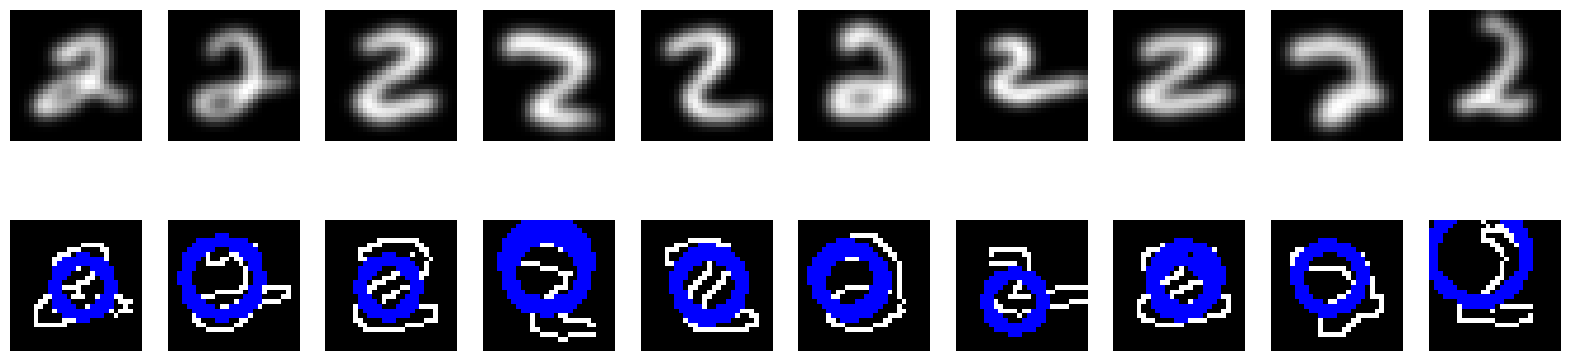

In [92]:
# for 10 images of one digit, detect the llines and circles using detect_shapes function 
# Choose only pictures of digit 2
two_images = train_images[train_labels == 2]

# Display them nicely using matplotlib in a one row and 10 columns
fig, axes = plt.subplots(2, 10, figsize=(20, 5))
for i in range(10):
    image, detected = detect_shapes(two_images[i])
    axes[0, i].imshow(image, cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(detected, cmap='gray')
    axes[1, i].axis('off')

## 01.c Detect Ransac circles for mnist one digit - 1
The idea was to see if ransac is able to actually detect one or circles with big radius so it is able to represent almost linear shape

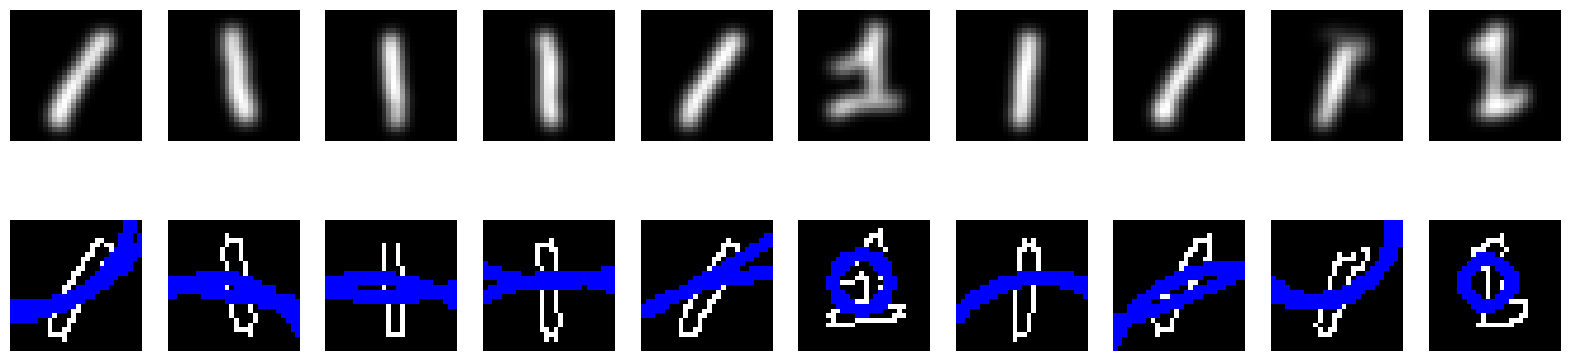

In [93]:
# for 10 images of one digit, detect the llines and circles using detect_shapes function 
# Choose only pictures of digit 1
one_images = train_images[train_labels == 1]

# Display them nicely using matplotlib in a one row and 10 columns, make the pictures bigger
fig, axes = plt.subplots(2, 10, figsize=(20, 5))
for i in range(10):

    image, detected = detect_shapes(one_images[i])
    axes[0, i].imshow(image, cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(detected, cmap='gray')
    axes[1, i].axis('off')

## 01.d Ransac for all digits

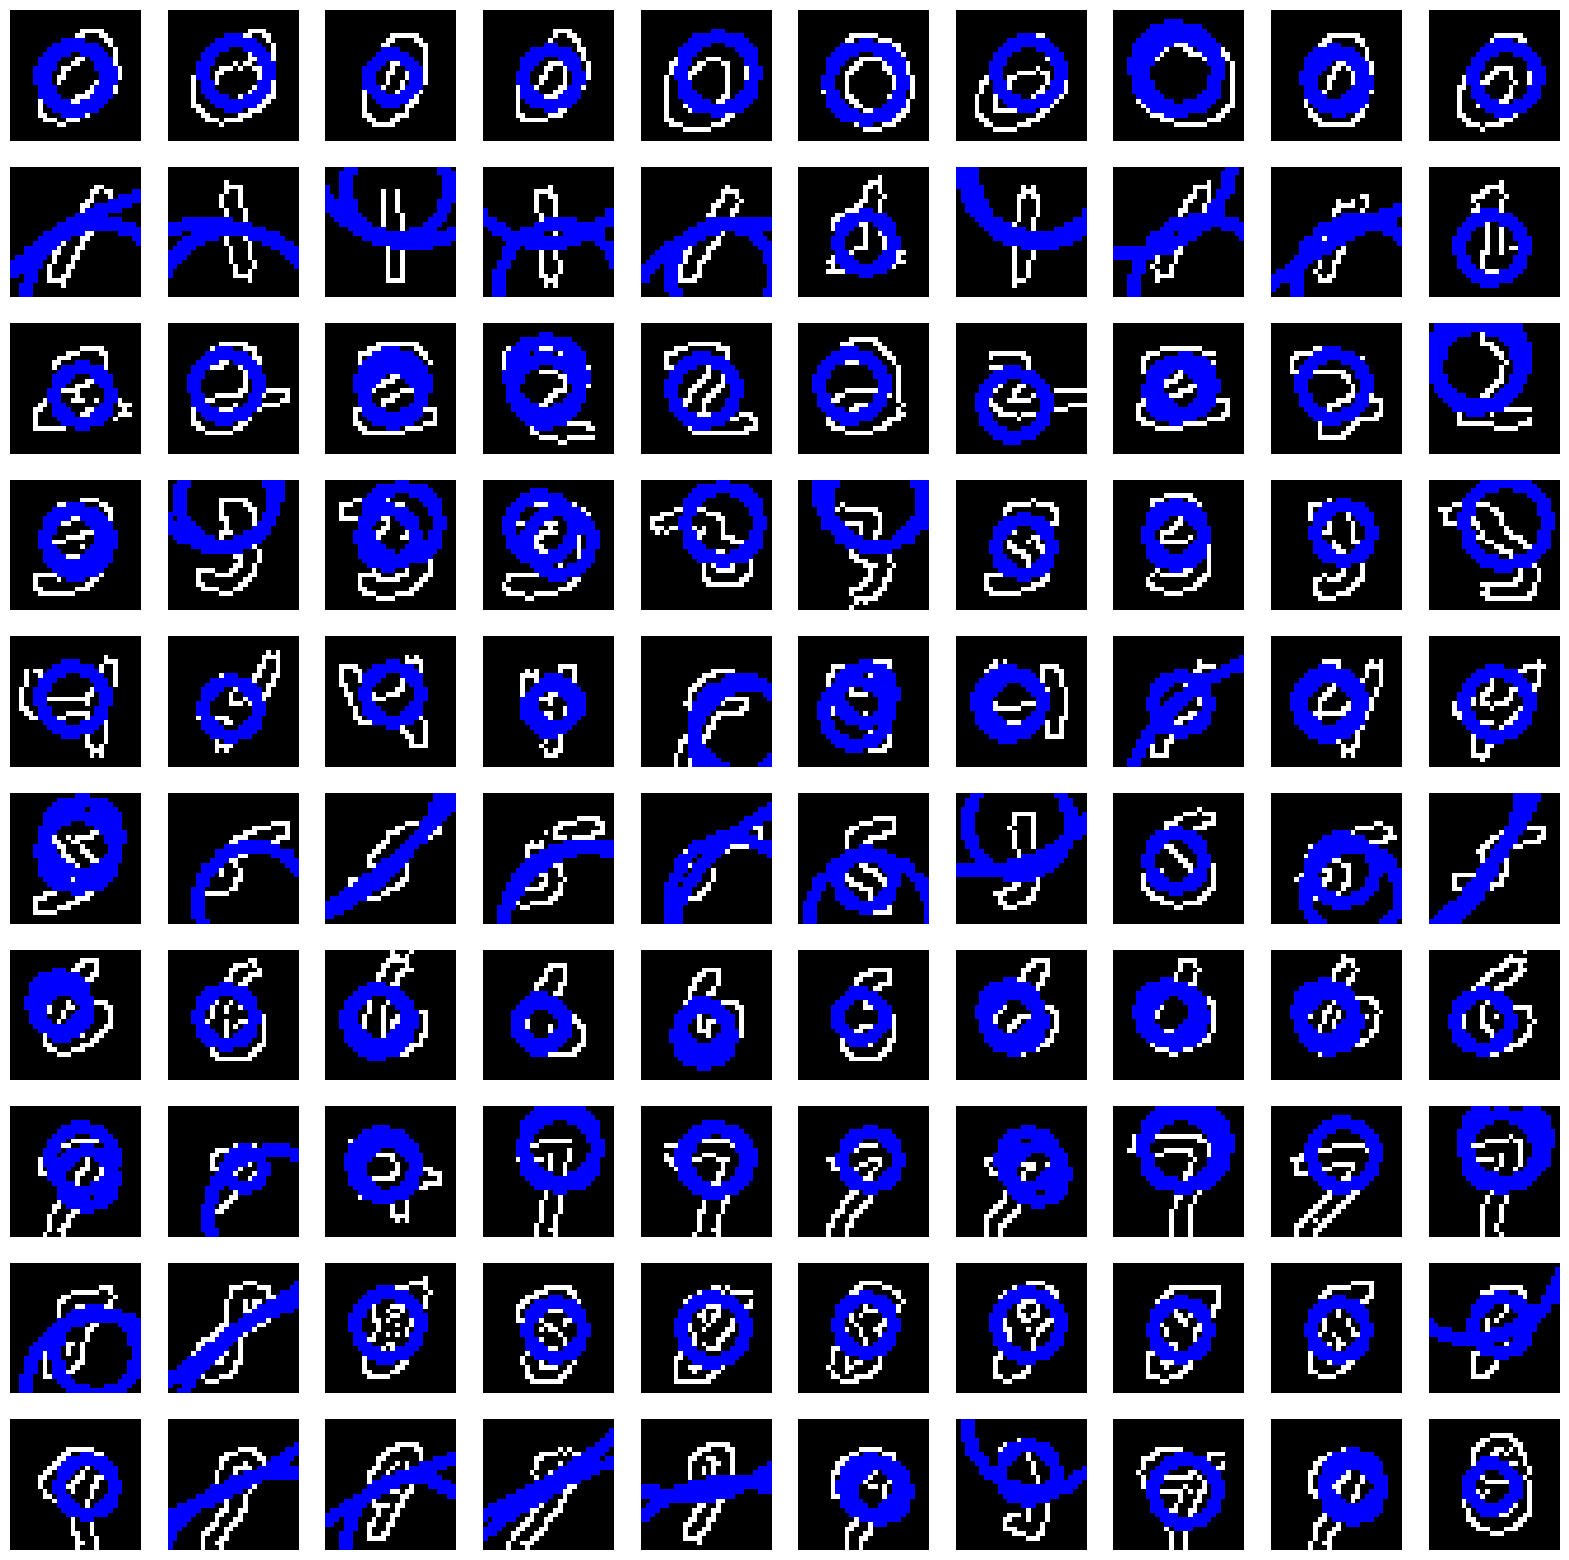

In [94]:
# Show how detection works for all the digits
fig, axes = plt.subplots(10, 10, figsize=(20, 20))
for i in range(10):
    images = train_images[train_labels == i]
    for j in range(10):
        image, detected = detect_shapes(images[j])
        axes[i, j].imshow(detected, cmap='gray')
        axes[i, j].axis('off')
        

## 02.a Use **Hough transforms** to find 
- lines, (in the end not the main objective)
- **circles**,
- elipses (finds none)

<<> it does not display correctly <>>

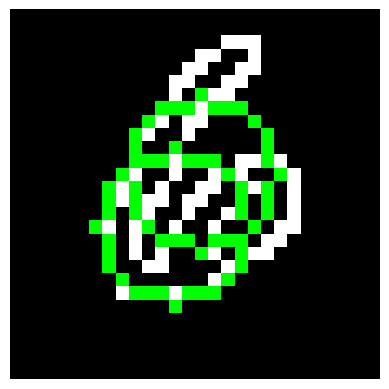

Top 3 Circles (with their overlap scores):
Circle 1: Center = (12, 16), Radius = 6, Overlap = 0.4247787610619469
Circle 2: Center = (14, 12), Radius = 6, Overlap = 0.35398230088495575


In [ ]:
def detect_circles_hough(image, min_radius=5, max_radius=200):
    # Convert to grayscale if necessary
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) if len(image.shape) == 3 else image

    # Apply Gaussian blur to reduce noise
    blurred = cv2.GaussianBlur(gray, (5, 5), 1)

    # Detect circles using Hough Circle Transform
    circles = cv2.HoughCircles(
        blurred,
        cv2.HOUGH_GRADIENT,
        dp=1,
        minDist=5,
        param1=50,
        param2=5,
        minRadius=min_radius,
        maxRadius=max_radius
    )
    
    if circles is not None:
        circles = np.round(circles[0, :]).astype("int")
        return circles
    return []

def generate_mask_for_three(image):
    # Create a binary mask for the number "3" in the image
    # You may use a predefined image of "3" or use image processing techniques to identify it
    # Here I'm assuming it's a known shape or we can detect it via thresholding, contours, etc.
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) if len(image.shape) == 3 else image
    _, mask = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
    
    # Optionally, refine the mask with contour detection or other methods
    return mask

def calculate_overlap(circle, mask):
    x, y, r = circle
    # Create a binary mask for the current circle
    circle_mask = np.zeros_like(mask, dtype=np.uint8)
    cv2.circle(circle_mask, (x, y), r, 255, -1)  # Circle mask with white circle
    
    # Calculate the intersection (overlap) between the circle and the image of 3
    intersection = cv2.bitwise_and(circle_mask, mask)
    overlap_area = np.sum(intersection == 255)
    total_area = np.sum(circle_mask == 255)
    
    # Calculate the overlap ratio: area of intersection / total area of the circle
    return overlap_area / total_area if total_area > 0 else 0

def fit_circles_to_three(image, top=2):
    # Generate a binary mask for the number "3"
    mask_of_three = generate_mask_for_three(image)

    # Detect circles in the image
    circles = detect_circles_hough(image, min_radius=3, max_radius=10)

    # Calculate overlap for each circle
    overlap_scores = []
    for circle in circles:
        overlap = calculate_overlap(circle, mask_of_three)
        overlap_scores.append((circle, overlap))
    
    # Sort circles by their overlap score in descending order
    overlap_scores.sort(key=lambda x: x[1], reverse=True)

    # Select the top circles with the highest overlap
    top_circles = [score[0] for score in overlap_scores[:top] if score[1] > 0.35]

    return top_circles, overlap_scores

# Example usage:
image = train_images[train_labels == 6][0]
image = cv2.Canny(image, 50, 150, apertureSize=3)
image = cv2.convertScaleAbs(image)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB for Matplotlib
top_circles, overlap_scores = fit_circles_to_three(image)

# Display the results using Matplotlib
image_copy = image.copy()

# Draw the top circles
for (x, y, r) in top_circles:
    cv2.circle(image_copy, (x, y), r, (0, 255, 0), 1)

plt.imshow(cv2.cvtColor(image_copy, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB for Matplotlib
plt.axis('off')  # Hide axes
plt.show()

# Optionally, print the overlap scores
print("Top 3 Circles (with their overlap scores):")
for i, circle in enumerate(top_circles):
    print(f"Circle {i+1}: Center = ({circle[0]}, {circle[1]}), Radius = {circle[2]}, Overlap = {overlap_scores[i][1]}")


## 02.b Detect Hough circles for mnist one digit - 3

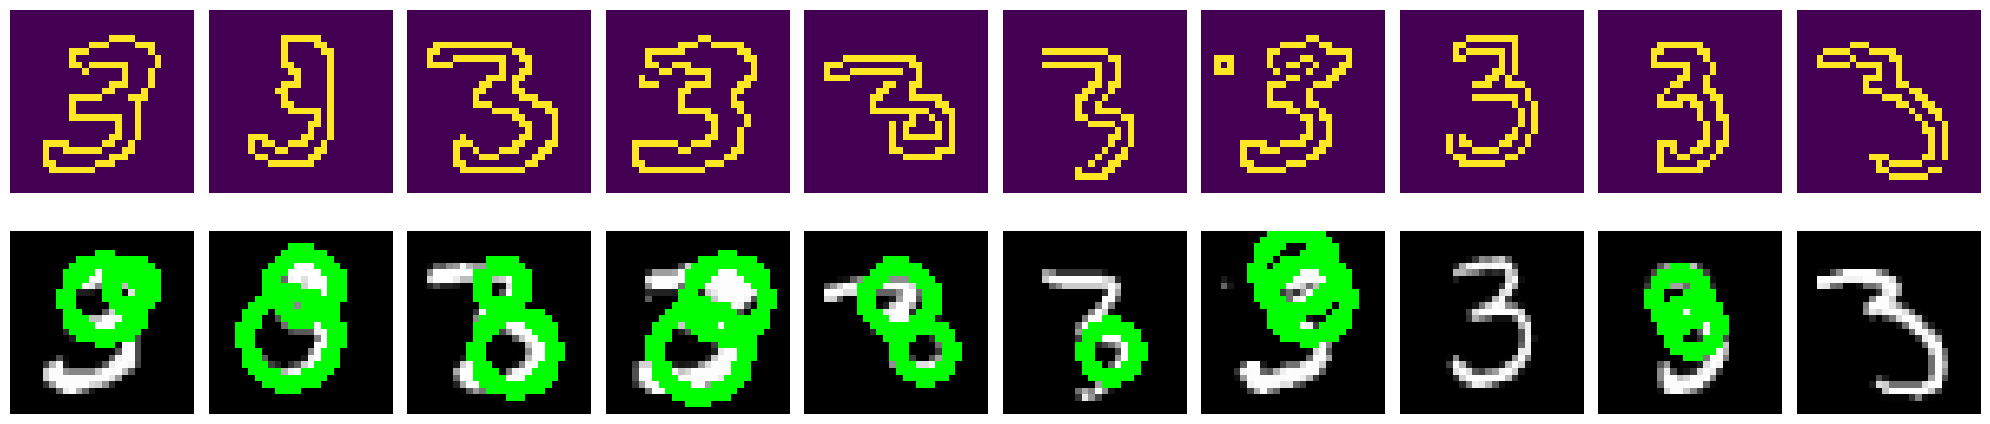

In [103]:
# Try to detect circles for 10 photos of digit 3:
# Choose only pictures of digit 3
three_images = train_images[train_labels == 3]

fig, axes = plt.subplots(2, 10, figsize=(20, 5))

for i in range(10):
    image = three_images[i]  # Your input image
    top_4_circles, _ = fit_circles_to_three(image)  # Detect circles
    image_copy = image.copy()  # Make a copy of the image for drawing circles
    image_copy = cv2.cvtColor(image_copy, cv2.COLOR_BGR2RGB)
    
    # Improve resolution for better visualization
    image_copy = cv2.convertScaleAbs(image_copy)
    

    for (x, y, r) in top_4_circles:
        # Draw the circle using OpenCV, in BGR format (0, 255, 0) for green
        cv2.circle(image_copy, (x, y), r, (0, 255, 0), 2)  # Green color with thickness 2

    # Convert BGR to RGB before displaying with matplotlib
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Display the original image
    #axes[0, i].imshow(image_rgb)  # Original image without circles
    can = cv2.Canny(image, 50, 150)
    axes[0, i].imshow(can)  # Original image without circles
    axes[0, i].axis('off')  # Hide axes
    axes[1, i].imshow(image_copy)  # Image with circles drawn
    axes[1, i].axis('off')  # Hide axes

plt.tight_layout()
plt.show()


## 02.c Detect Hough circles for all digits

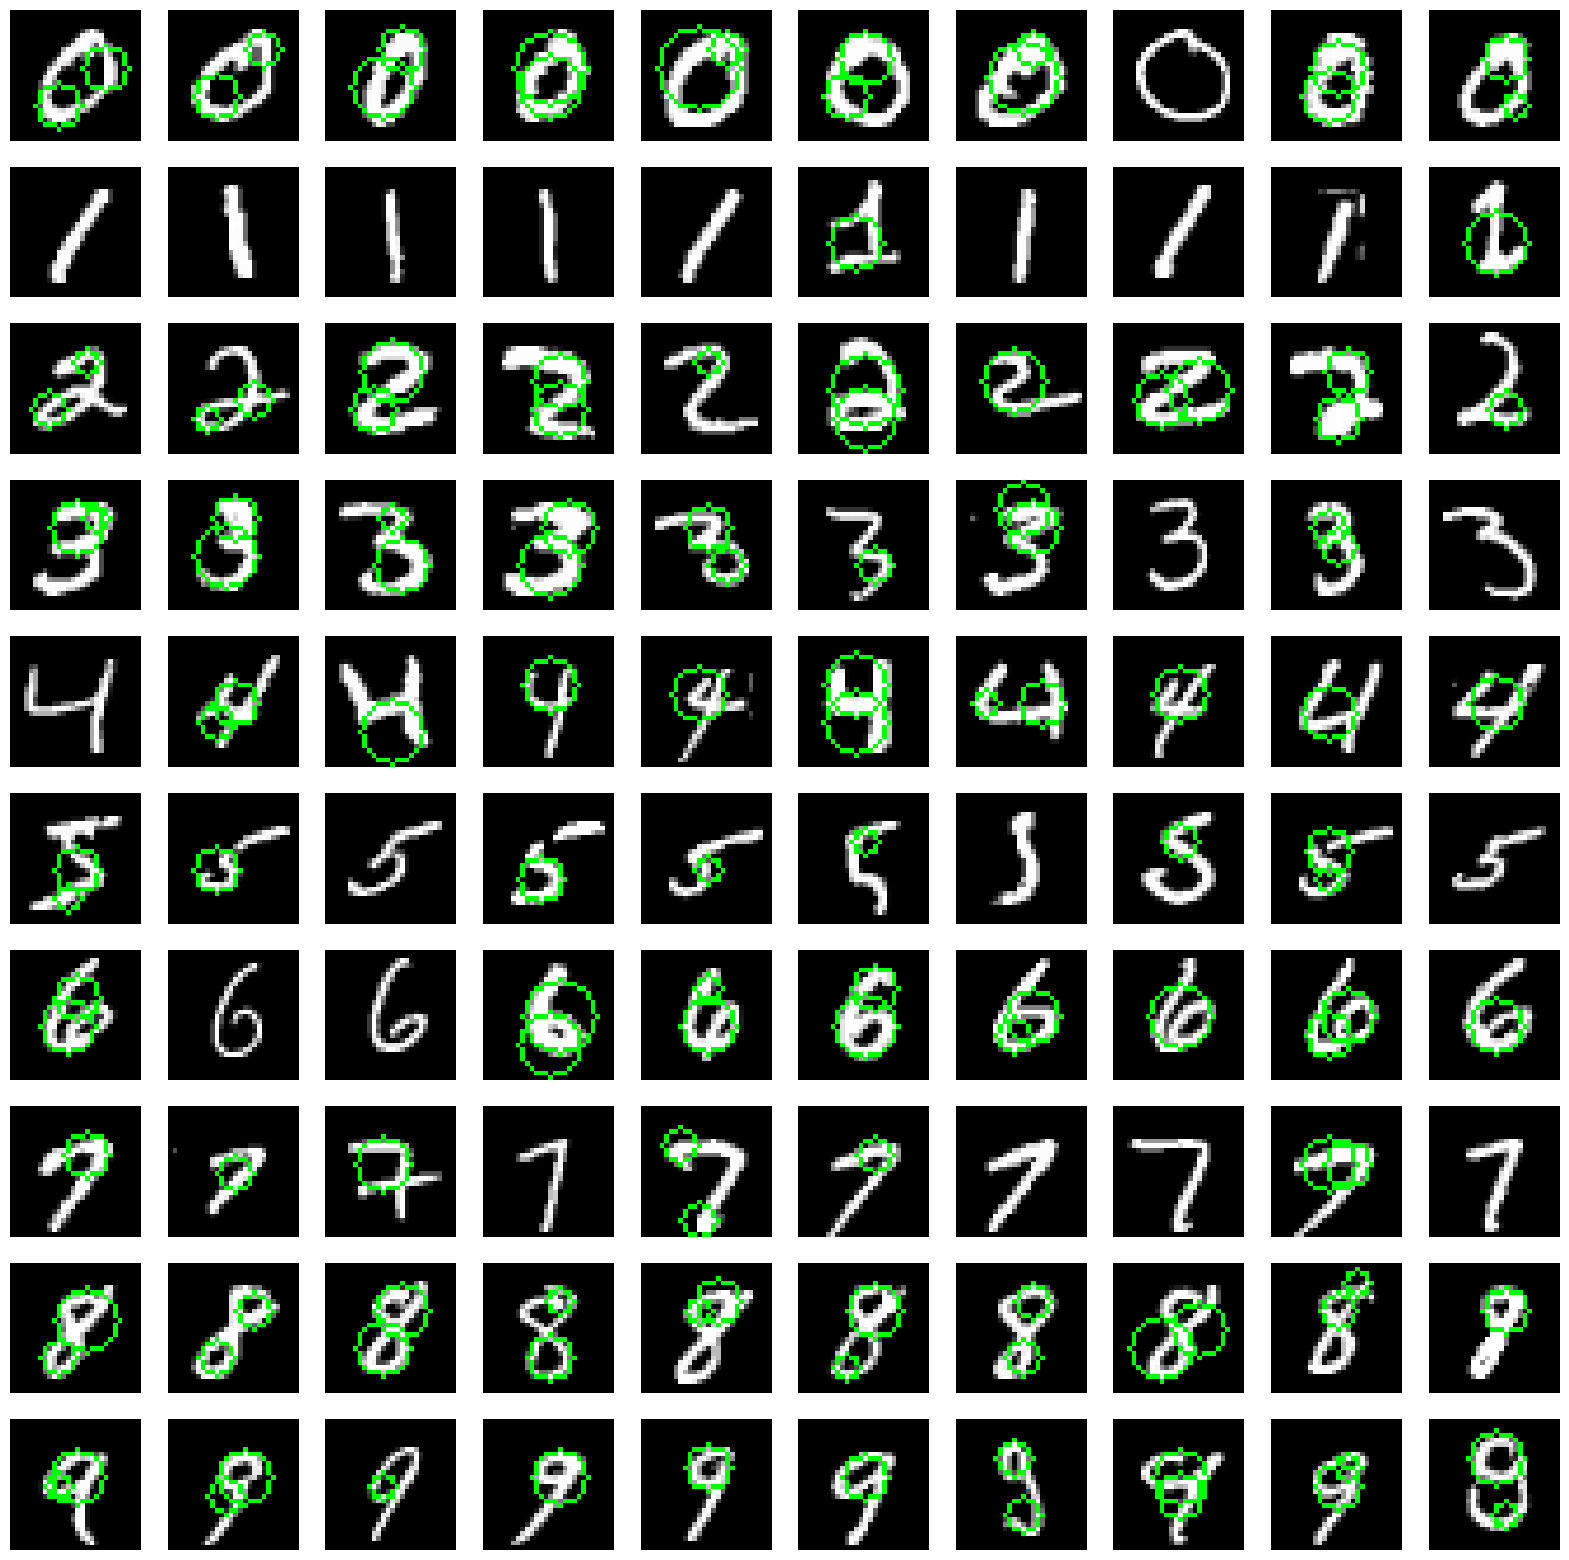

In [105]:
# Try to detect circles for 10 photos of all digits:
fig, axes = plt.subplots(10, 10, figsize=(20, 20))

for i in range(10):
    images = train_images[train_labels == i]
    for j in range(10):
        image = images[j]  # Your input image
        top_3_circles, _ = fit_circles_to_three(image)  # Detect circles
        image_copy = image.copy()  # Make a copy of the image for drawing circles
        
        image_copy = cv2.cvtColor(image_copy, cv2.COLOR_BGR2RGB)
        
        # Improve resolution for better visualization
        for (x, y, r) in top_3_circles:
            # Draw the circle using OpenCV, in BGR format (0, 255, 0) for green
            cv2.circle(image_copy, (x, y), r, (0, 255, 0), 1)  # Green color with thickness 2

        # Convert BGR to RGB before displaying with matplotlib
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Display the original image
        axes[i, j].imshow(image_rgb)  # Original image without circles
        axes[i, j].axis('off')  # Hide axes
        axes[i, j].imshow(image_copy)
        axes[i, j].axis('off')

**TODO**: work on probabilistic hough transform
Try to understand what is:
- rho: 
- theta: 
- threshold:
- min length
- max gap

## 03.a Try to **fit elipses** using open cv function

c:\Users\ewa.miazga\miniconda3\envs\edge-detection\lib\site-packages\skimage\measure\fit.py:517: RuntimeWarning: divide by zero encountered in scalar divide
  width = np.sqrt(2 * numerator / denominator1)
c:\Users\ewa.miazga\miniconda3\envs\edge-detection\lib\site-packages\skimage\measure\fit.py:517: RuntimeWarning: invalid value encountered in sqrt
  width = np.sqrt(2 * numerator / denominator1)
c:\Users\ewa.miazga\miniconda3\envs\edge-detection\lib\site-packages\skimage\measure\fit.py:578: RuntimeWarning: overflow encountered in scalar power
  return (xi - xt) ** 2 + (yi - yt) ** 2


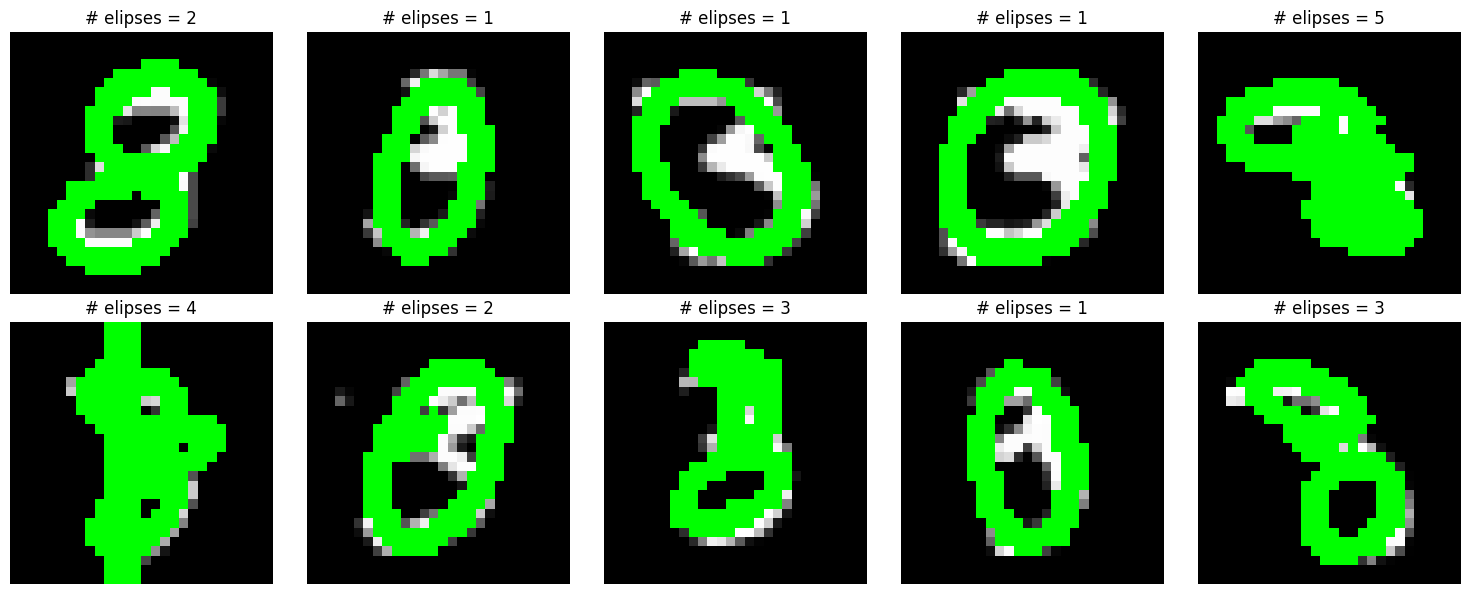

In [ ]:
def fit_ellipses_ransac(image):
    """Fit ellipses to the contours of a digit in the image using RANSAC."""
    # Convert the image to binary
    _, binary_image = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY_INV)
    edges = cv2.Canny(binary_image, 50, 150, apertureSize=3)

    contours = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0]
    
    
    # Fit ellipses to contours using RANSAC
    ellipses = []
    for contour in contours:
        if len(contour) >= 5:  # RANSAC requires at least 5 points
            contour = contour.squeeze()
            model_ellipse, inliers = ransac(contour, EllipseModel, min_samples=5, residual_threshold=1000, max_trials=1000)
            if model_ellipse:
                xc, yc, a, b, theta = model_ellipse.params
                ellipses.append(((xc, yc), (2*a, 2*b), np.degrees(theta)))
    
    return ellipses

def draw_ellipses(image, ellipses):
    """Draw ellipses on the image."""
    output_image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    for ellipse in ellipses:
        cv2.ellipse(output_image, ellipse, (0, 255, 0), 2)
    return output_image

# Load the MNIST dataset
(train_images, train_labels), _ = mnist.load_data()

# Select 10 images of the digit '3'
digit_images = train_images[train_labels == 3][:10]

# Fit ellipses to each image and display the results
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, image in enumerate(digit_images):
    ellipses = fit_ellipses_ransac(image)
    output_image = draw_ellipses(image, ellipses)
    
    axes[i].imshow(output_image)
    axes[i].set_title(f"# elipses = {len(ellipses)}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## 03.b Fit hough elipses for all the digits

The results are for digit: 0


c:\Users\ewa.miazga\miniconda3\envs\edge-detection\lib\site-packages\skimage\measure\fit.py:517: RuntimeWarning: divide by zero encountered in scalar divide
  width = np.sqrt(2 * numerator / denominator1)
c:\Users\ewa.miazga\miniconda3\envs\edge-detection\lib\site-packages\skimage\measure\fit.py:517: RuntimeWarning: invalid value encountered in sqrt
  width = np.sqrt(2 * numerator / denominator1)


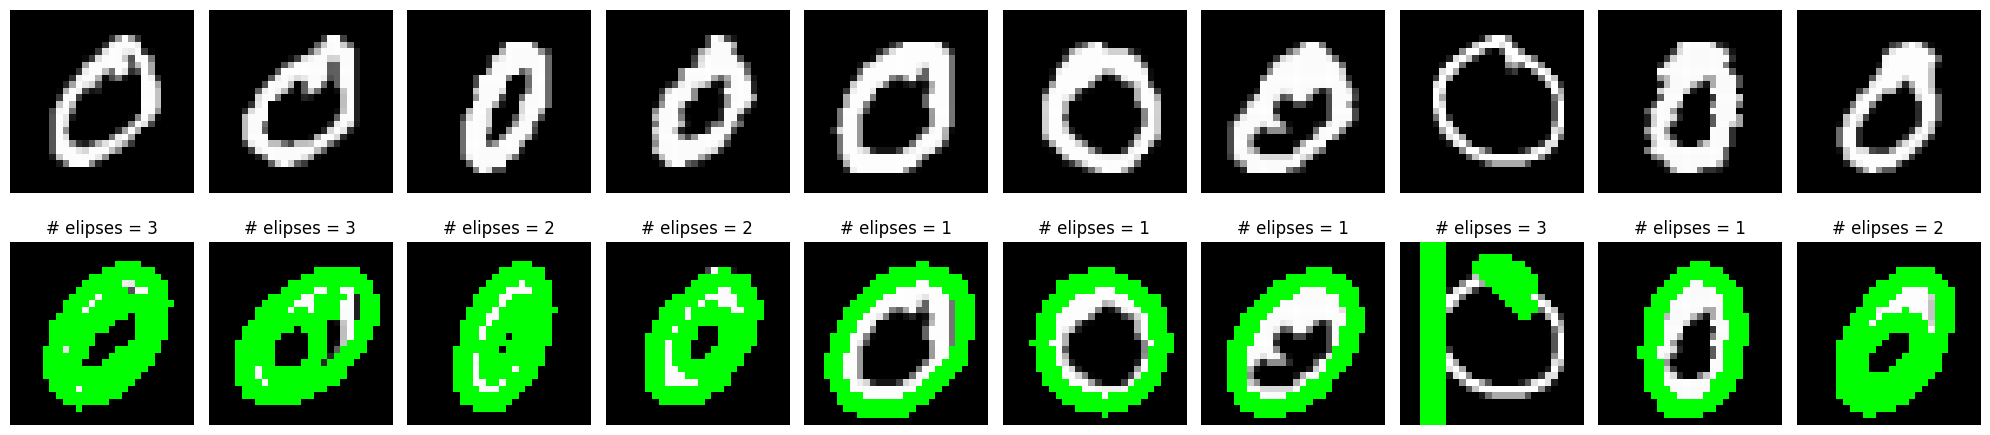

The results are for digit: 1


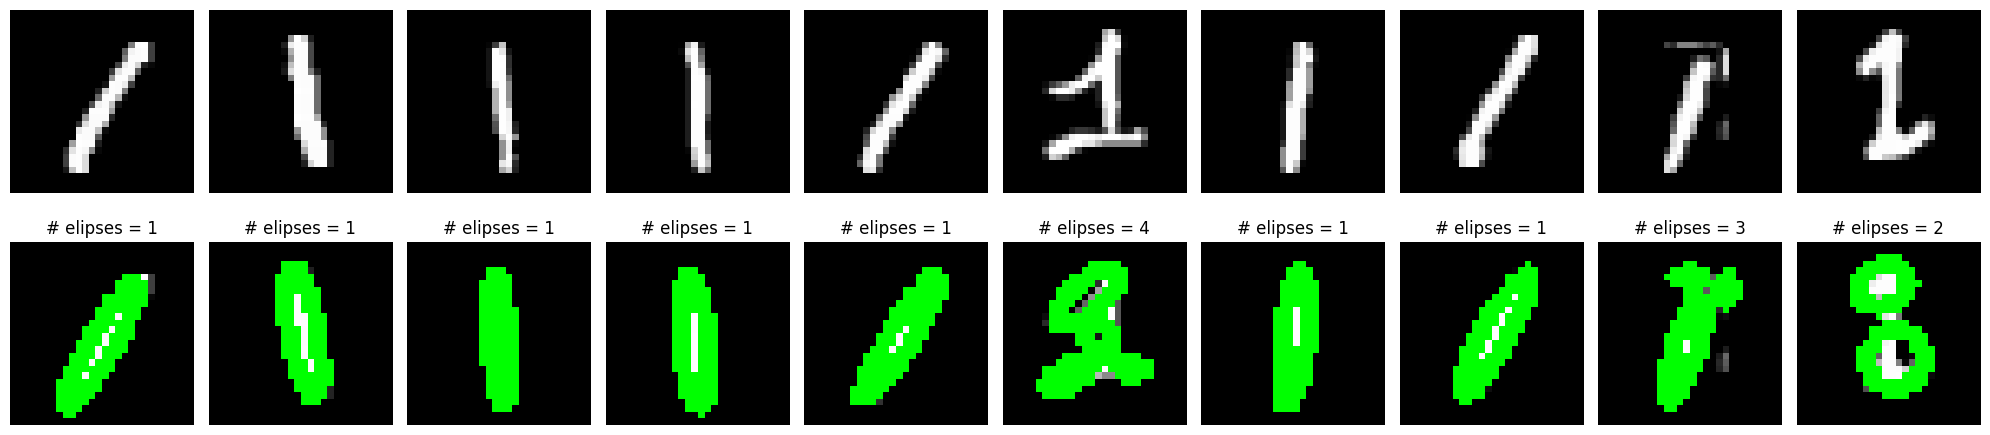

The results are for digit: 2


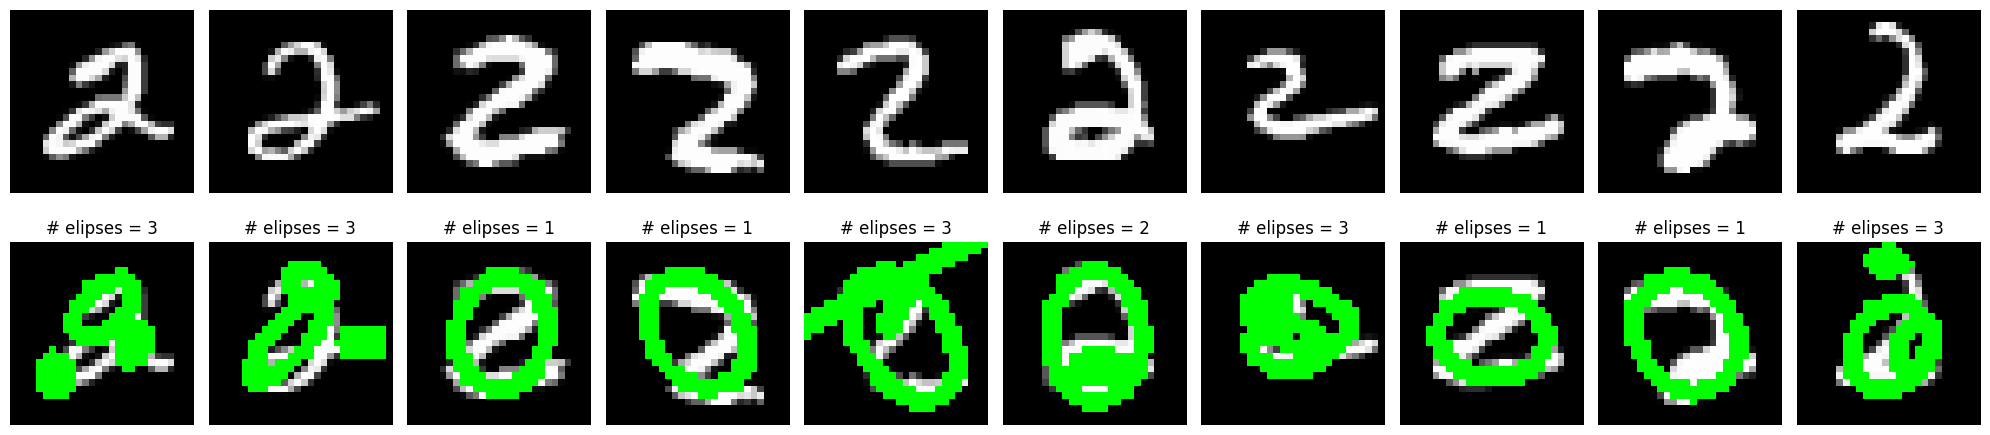

The results are for digit: 3


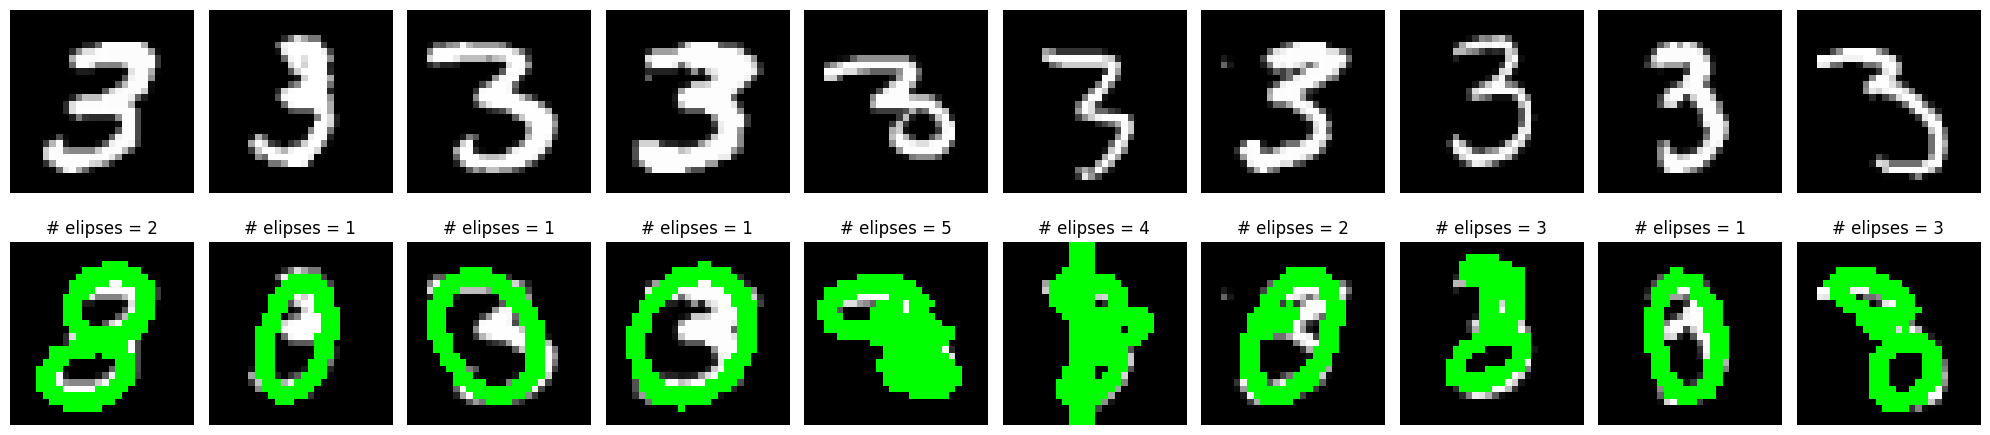

The results are for digit: 4


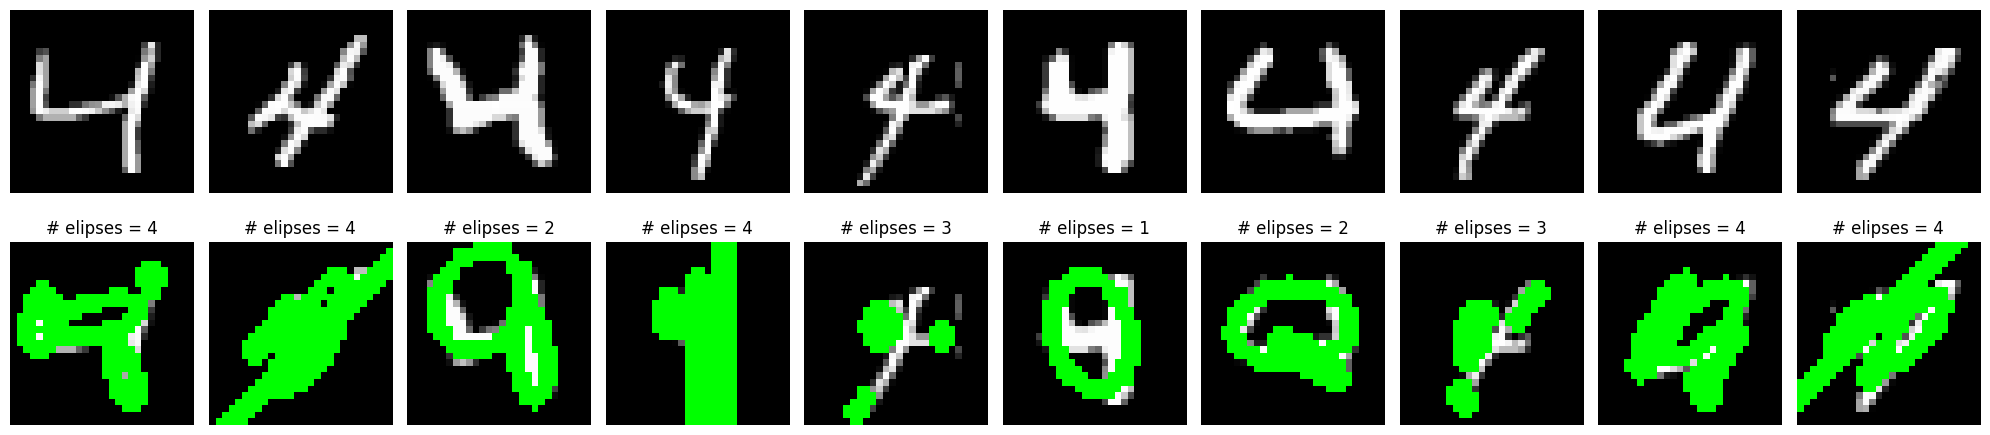

The results are for digit: 5


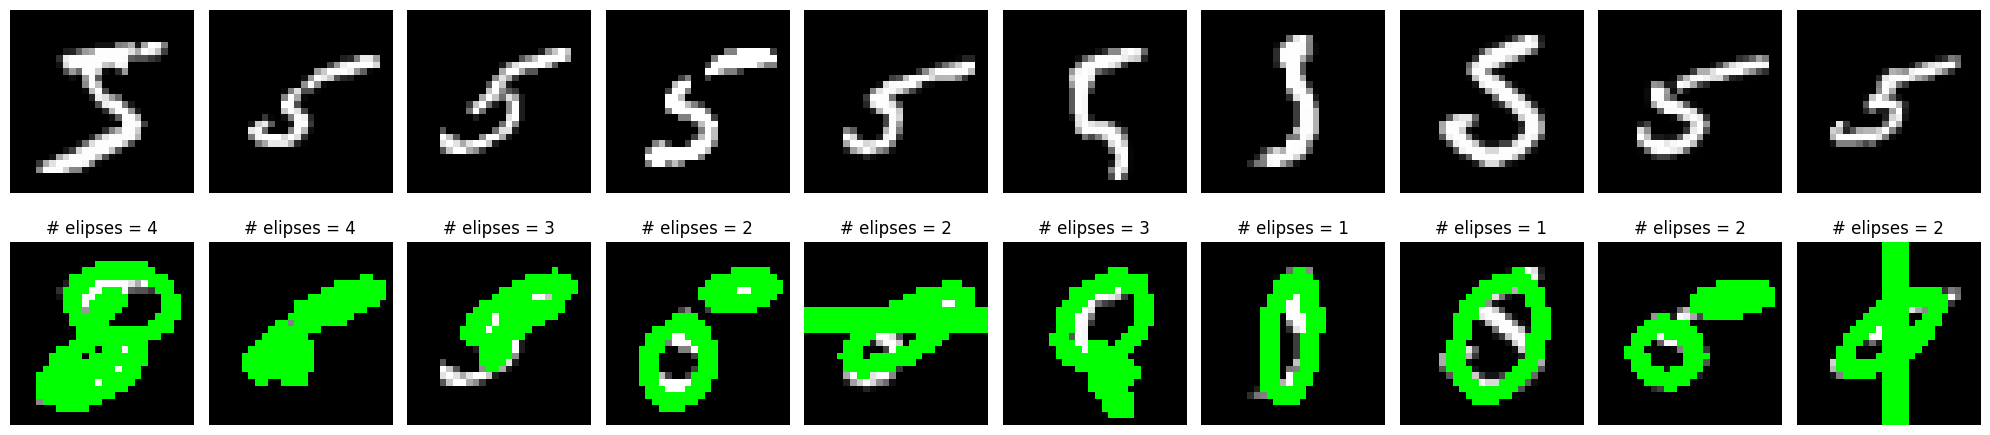

The results are for digit: 6


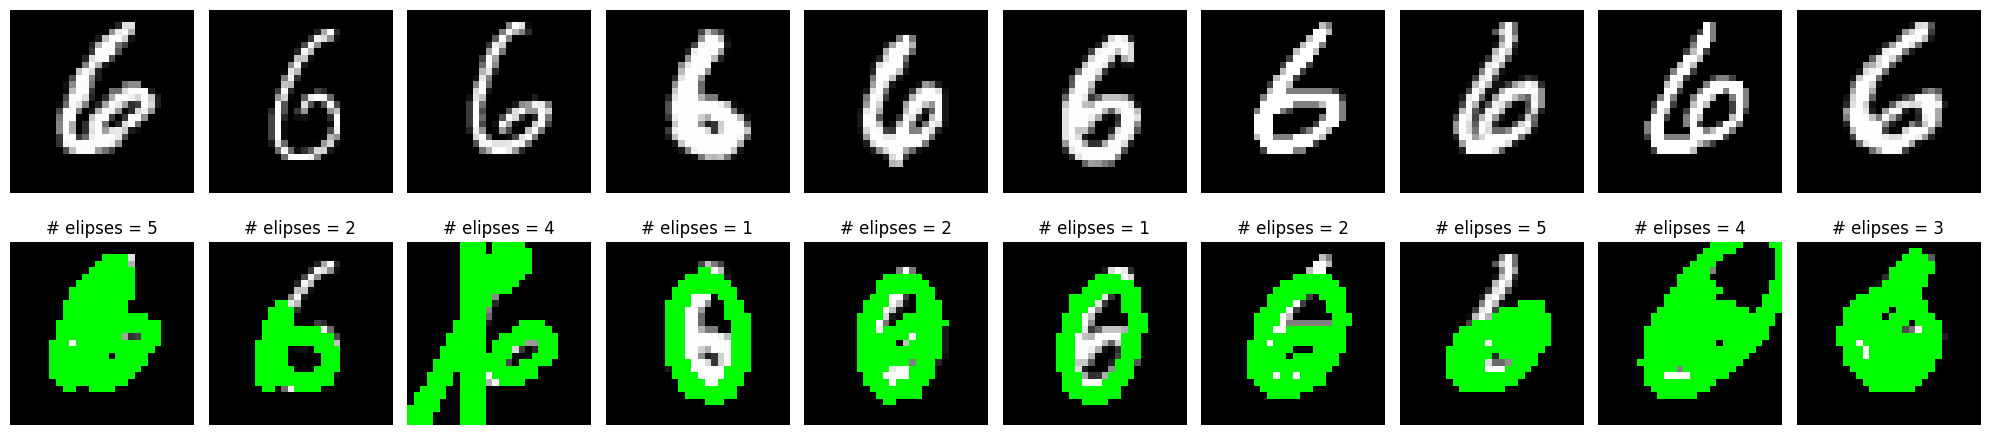

The results are for digit: 7


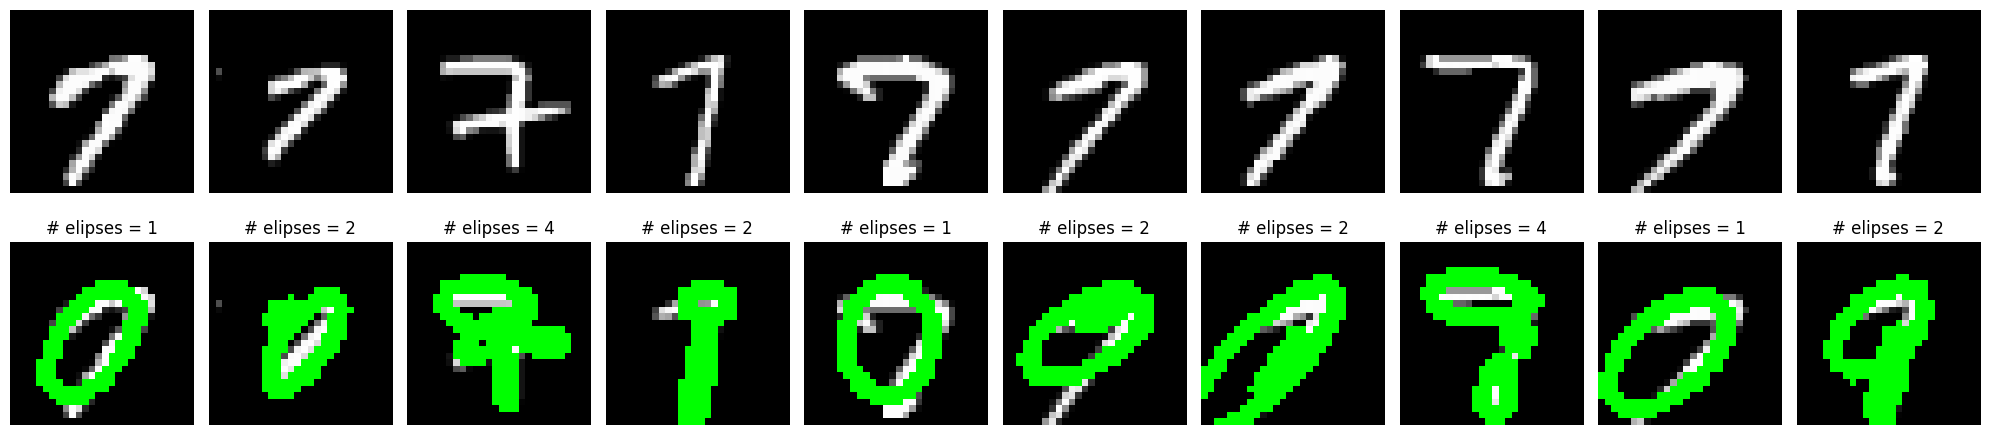

The results are for digit: 8


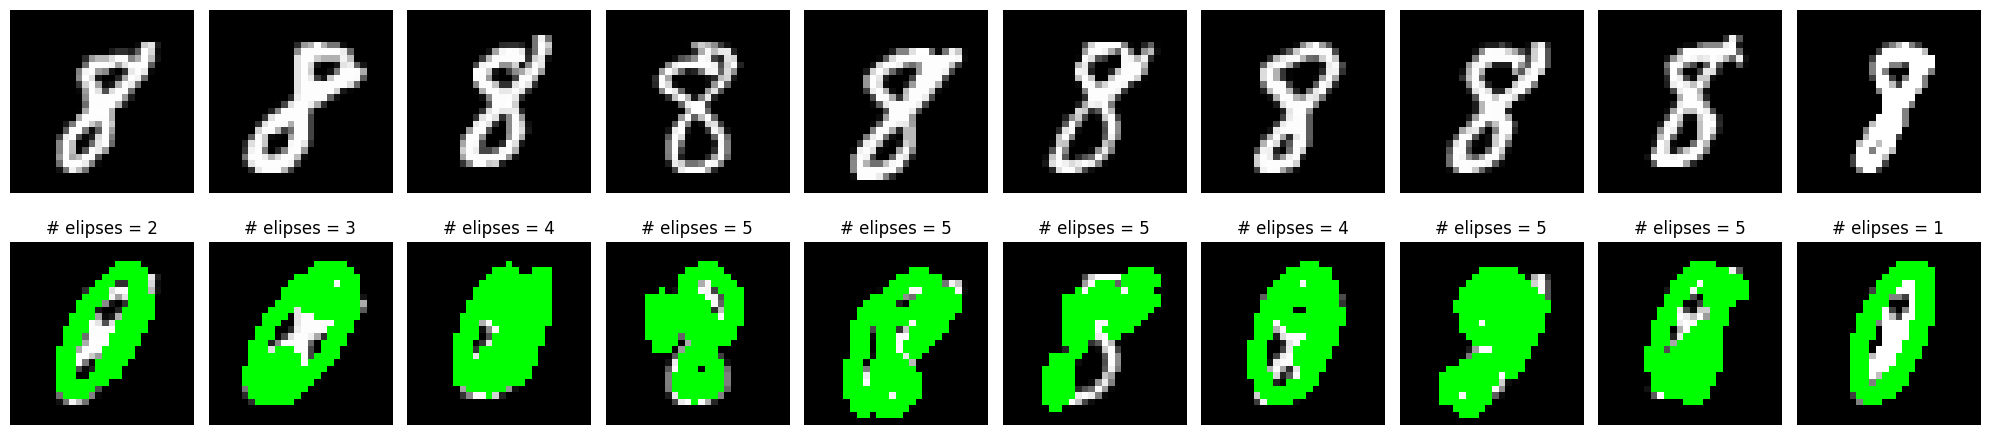

The results are for digit: 9


c:\Users\ewa.miazga\miniconda3\envs\edge-detection\lib\site-packages\skimage\measure\fit.py:962: UserWarning: No inliers found. Model not fitted
  warn("No inliers found. Model not fitted")


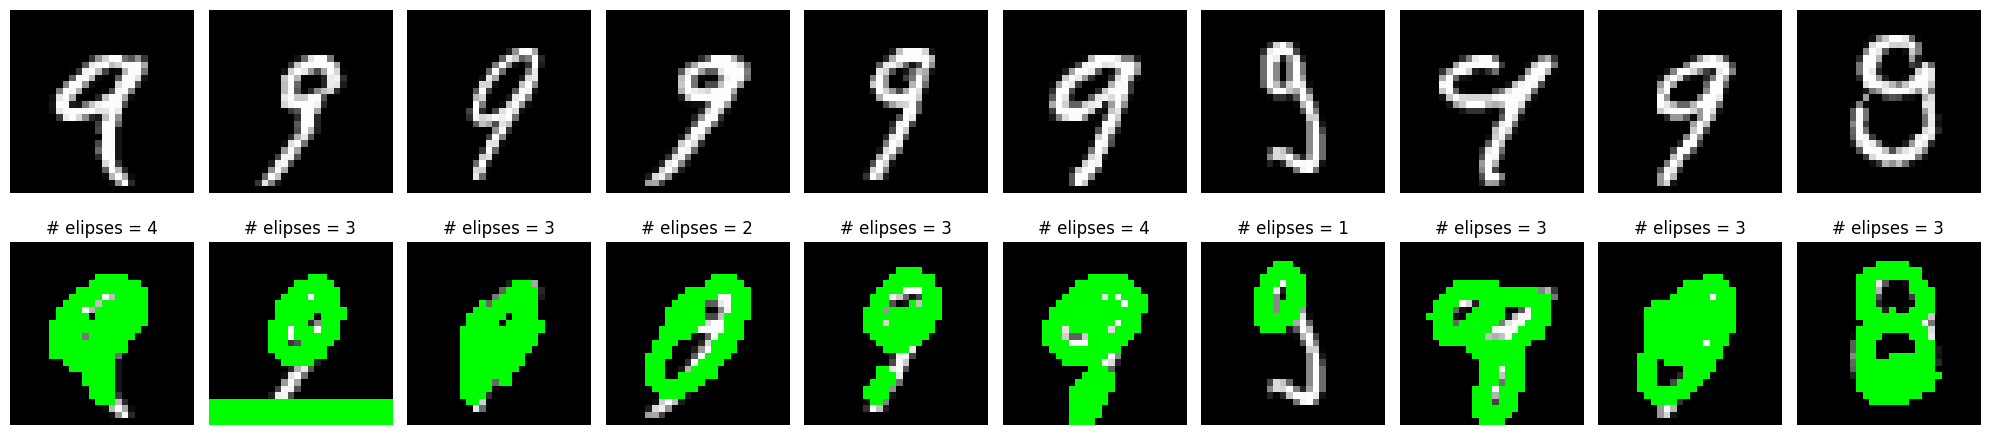

In [ ]:
def fit_ellipses_ransac(image):
    """Fit ellipses to the contours of a digit in the image using RANSAC."""
    # Convert the image to binary
    _, binary_image = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY_INV)
    edges = cv2.Canny(binary_image, 50, 150, apertureSize=3)

    contours = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0]
    
    
    # Fit ellipses to contours using RANSAC
    ellipses = []
    for contour in contours:
        if len(contour) >= 5:  # RANSAC requires at least 5 points
            contour = contour.squeeze()

            try:
                model_ellipse, inliers = ransac(contour, EllipseModel, min_samples=5, residual_threshold=5, max_trials=100000)
            except TypeError:
                continue
                
            #model_ellipse, inliers = ransac(contour, EllipseModel, min_samples=5, residual_threshold=5, max_trials=1000)
            if model_ellipse:
                xc, yc, a, b, theta = model_ellipse.params
                ellipses.append(((xc, yc), (2*a, 2*b), np.degrees(theta)))

                if len(ellipses) >= 5: # max_ellipses
                    break
    
    return ellipses

def draw_ellipses(image, ellipses):
    """Draw ellipses on the image."""
    output_image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    for ellipse in ellipses:
        cv2.ellipse(output_image, ellipse, (0, 255, 0), 2)
    return output_image

# Load the MNIST dataset
(train_images, train_labels), _ = mnist.load_data()

# Select 10 images of the digit '3'
for i in range(10):
    print(f"The results are for digit: {i}")
    digit_images = train_images[train_labels == i][:10]

    # Fit ellipses to each image and display the results
    fig, axes = plt.subplots(2, 10, figsize=(20, 5))
    
    for j, image in enumerate(digit_images):
        # display original image 
        axes[0, j].imshow(image, cmap='gray')
        axes[0, j].axis('off')
                
        ellipses = fit_ellipses_ransac(image)
        output_image = draw_ellipses(image, ellipses)
        
        axes[1, j].imshow(output_image)
        axes[1, j].set_title(f"# elipses = {len(ellipses)}")
        axes[1, j].axis('off')

        
    plt.tight_layout()
    plt.show()


## 04.a **Hough lines** fitted to the digits

In [ ]:
def detect_lines_hough(image):
    # Convert the image to grayscale if it's not already
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image

    # Apply Canny edge detection
    edges = cv2.Canny(gray, 50, 150, apertureSize=3)

    # Detect lines using Hough Line Transform (Standard Hough Transform)
    # for normal hough transform thereshold - 15
    lines = cv2.HoughLinesP(edges, 1, np.pi / 180, 19)  # Change threshold (100) if needed

    if lines is not None:
        for line in lines:
            # Extract the line parameters (rho, theta)
            # Normal hough transform
            # rho, theta = line[0]
            # probabilistic Hough line transform
            rho, theta, _, _ = line[0]
            # Convert polar to Cartesian coordinates
            a = np.cos(theta)
            b = np.sin(theta)
            x0 = a * rho
            y0 = b * rho
            x1 = int(x0 + 1000 * (-b))
            y1 = int(y0 + 1000 * (a))
            x2 = int(x0 - 1000 * (-b))
            y2 = int(y0 - 1000 * (a))
            cv2.line(image, (x1, y1), (x2, y2), (0, 255, 0), 2)  # Draw green line

    return image

## 04.b Hough lines fitted for one digit - 1

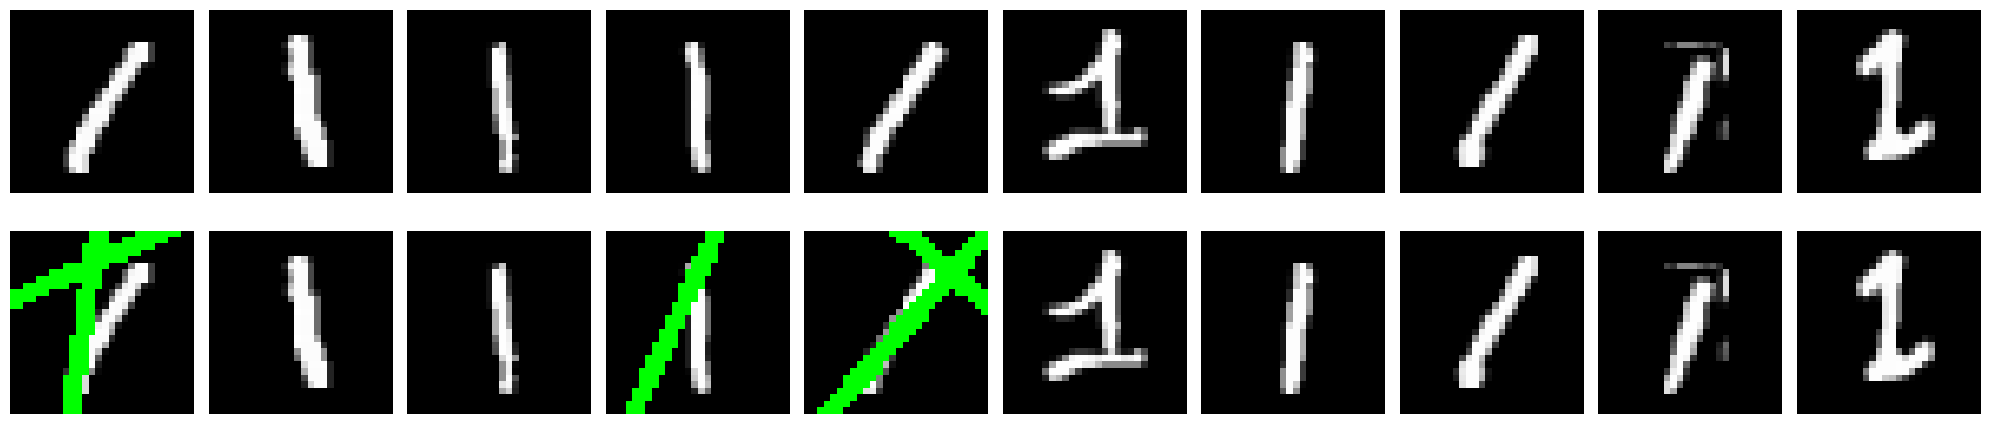

In [25]:
# Assuming 'three_images' and 'fit_circles_to_three' are already defined

fig, axes = plt.subplots(2, 10, figsize=(20, 5))

for i in range(10):
    image = train_images[train_labels == 1][i]  # Your input image
    image_copy = image.copy()  # Make a copy of the image for drawing lines
    image_copy = cv2.cvtColor(image_copy, cv2.COLOR_BGR2RGB)
        
    # Improve resolution for better visualization
    image_copy = cv2.convertScaleAbs(image_copy)

    # Detect lines using Hough Line Transform
    image_with_lines = detect_lines_hough(image_copy)

    # Convert the images to RGB before displaying
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Display the original image
    axes[0, i].imshow(image_rgb)  # Original image without lines
    axes[0, i].axis('off')  # Hide axes
    axes[1, i].imshow(image_with_lines)  # Image with lines drawn
    axes[1, i].axis('off')  # Hide axes

plt.tight_layout()
plt.show()


## 04.c Hough lines fitted for all digits
*Not successful*

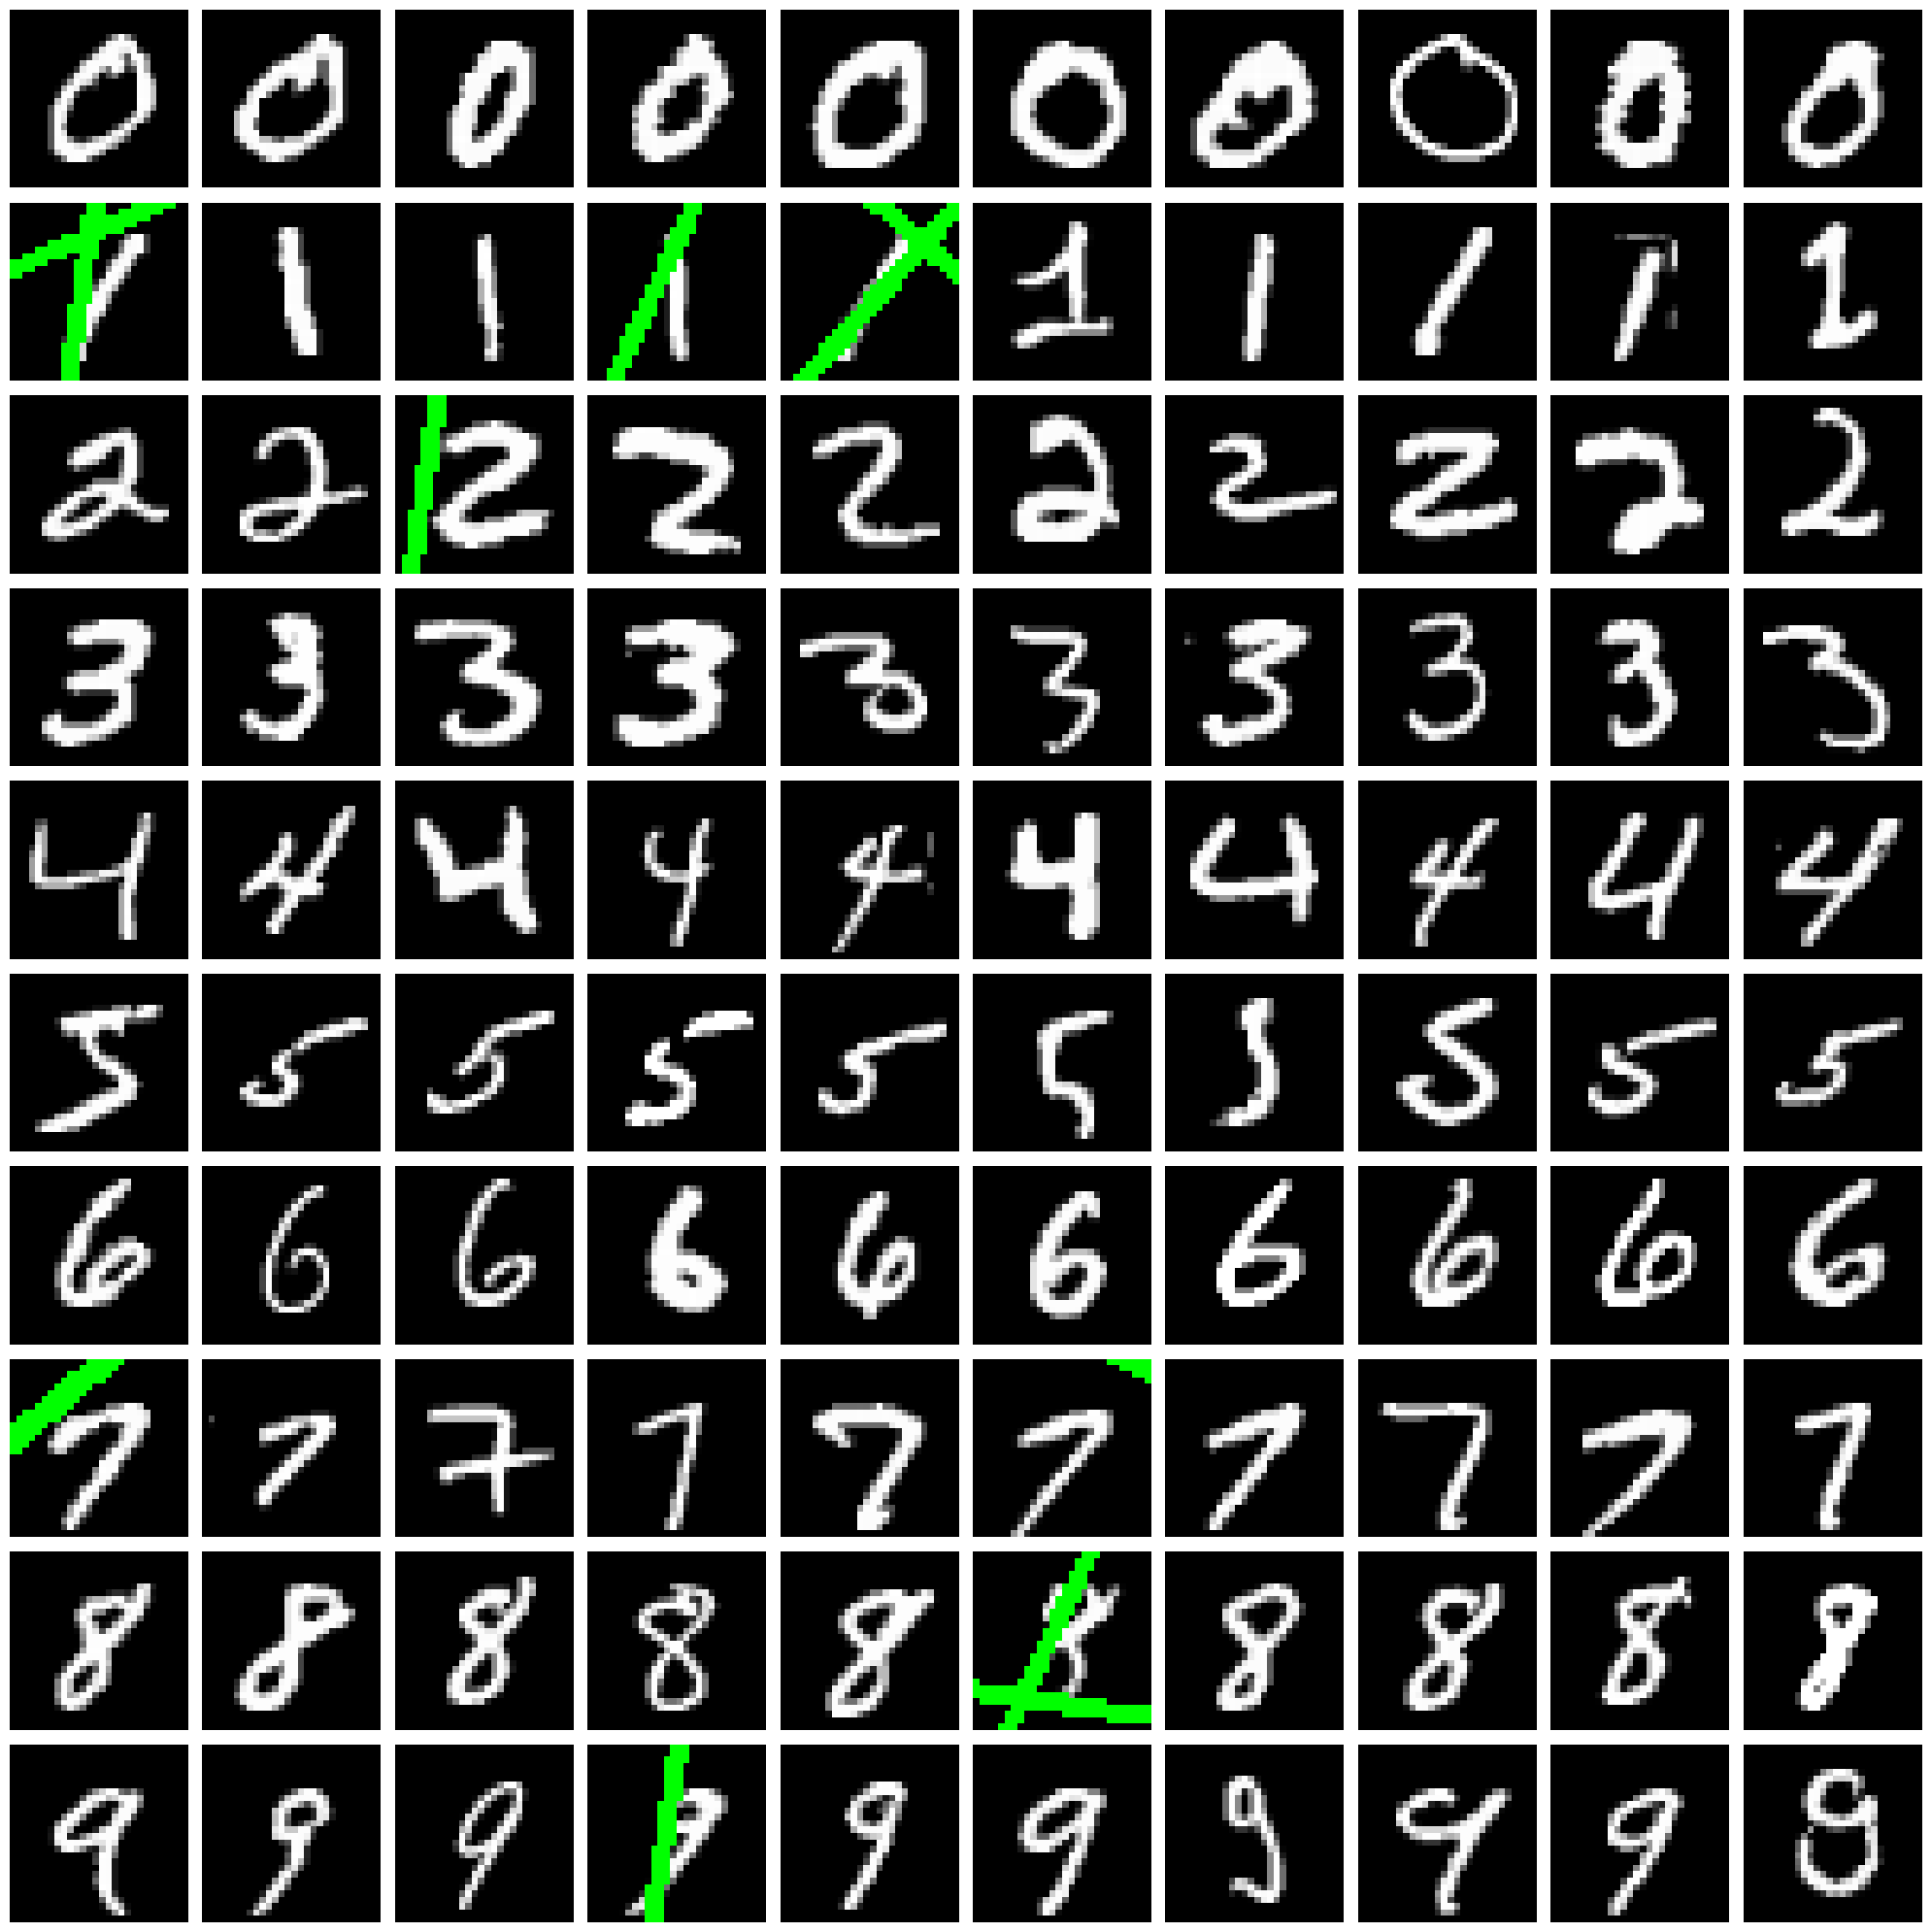

In [96]:
# for all the digits
# Assuming 'train_images' and 'fit_circles_to_three' are already defined

fig, axes = plt.subplots(10, 10, figsize=(20, 20))

for i in range(10):
    images = train_images[train_labels == i]
    for j in range(10):
        image = images[j]  # Your input image
        image_copy = image.copy()  # Make a copy of the image for drawing lines
        image_copy = cv2.cvtColor(image_copy, cv2.COLOR_BGR2RGB)
        
        # Improve resolution for better visualization
        image_copy = cv2.convertScaleAbs(image_copy)

        # Detect lines using Hough Line Transform
        image_with_lines = detect_lines_hough(image_copy)

        # Convert the images to RGB before displaying
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Display the original image
        axes[i, j].imshow(image_rgb)  # Original image without lines
        axes[i, j].axis('off')  # Hide axes
        axes[i, j].imshow(image_with_lines)  # Image with lines drawn
        axes[i, j].axis('off')  # Hide axes

plt.tight_layout()
plt.show()


## 05.a Detection of shapes using **2d Gaussian splatting**
- just one gaussian 

Fitted Parameters:
Amplitude: 0.7907932717687663
Center: (15.175061698381736, 13.527557565547845)
Sigma_x: 4.17417257148037
Sigma_y: 8.898147550266197
Theta: -0.3952945139948715
Offset: -0.03246655460399896


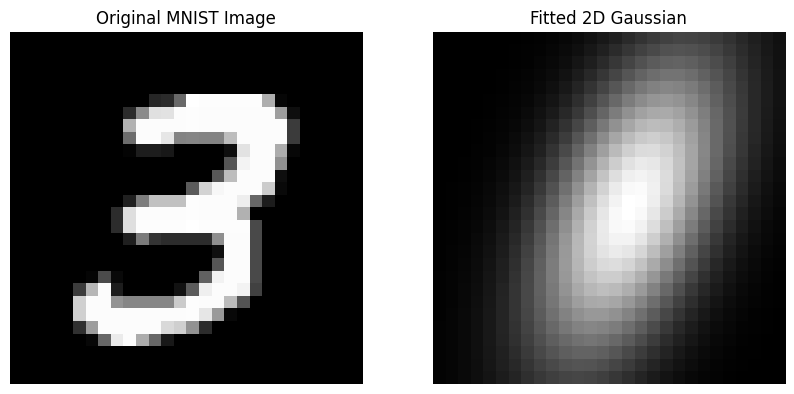

In [109]:
def gaussian_2d(coords, amplitude, xo, yo, sigma_x, sigma_y, theta, offset):
    """
    2D Gaussian function to fit to the MNIST image.
    """
    x, y = coords
    xo = float(xo)
    yo = float(yo)
    
    # Rotation transformation
    a = (np.cos(theta)**2) / (2 * sigma_x**2) + (np.sin(theta)**2) / (2 * sigma_y**2)
    b = -(np.sin(2 * theta)) / (4 * sigma_x**2) + (np.sin(2 * theta)) / (4 * sigma_y**2)
    c = (np.sin(theta)**2) / (2 * sigma_x**2) + (np.cos(theta)**2) / (2 * sigma_y**2)
    
    g = offset + amplitude * np.exp(- (a * (x - xo)**2 + 2 * b * (x - xo) * (y - yo) + c * (y - yo)**2))
    
    return g.ravel()  # Return as a 1D array for curve fitting

def fit_gaussian_to_mnist(image):
    """
    Fits a 2D Gaussian to a given MNIST image.
    """
    # Normalize image to [0,1] range
    image = image / 255.0  

    # Get x, y coordinate grid
    x = np.arange(image.shape[1])
    y = np.arange(image.shape[0])
    X, Y = np.meshgrid(x, y)

    # Flatten image and coordinates
    xdata = np.vstack((X.ravel(), Y.ravel()))
    ydata = image.ravel()

    # Initial parameter guesses
    amplitude_guess = np.max(ydata)
    xo_guess, yo_guess = np.mean(x), np.mean(y)  # Center of the image
    sigma_x_guess, sigma_y_guess = 5, 5  # Approximate standard deviations
    theta_guess = 0  # No rotation initially
    offset_guess = np.min(ydata)

    initial_guess = [amplitude_guess, xo_guess, yo_guess, sigma_x_guess, sigma_y_guess, theta_guess, offset_guess]

    # Fit the 2D Gaussian
    try:
        params, _ = curve_fit(gaussian_2d, xdata, ydata, p0=initial_guess)
    except RuntimeError:
        print("Gaussian fit did not converge")
        return None

    return params

# Load the MNIST dataset
(train_images, train_labels), (_, _) = mnist.load_data()

# Select a sample image (e.g., an image of '3')
image = train_images[train_labels == 3][0]  # Take the first '3' digit

# Fit the Gaussian
params = fit_gaussian_to_mnist(image)

if params is not None and params.any():
    amplitude, xo, yo, sigma_x, sigma_y, theta, offset = params
    print(f"Fitted Parameters:\nAmplitude: {amplitude}\nCenter: ({xo}, {yo})\nSigma_x: {sigma_x}\nSigma_y: {sigma_y}\nTheta: {theta}\nOffset: {offset}")

    # Generate fitted Gaussian image
    x = np.arange(image.shape[1])
    y = np.arange(image.shape[0])
    X, Y = np.meshgrid(x, y)
    fitted_gaussian = gaussian_2d((X, Y), *params).reshape(image.shape)

    # Plot the original and fitted Gaussian
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(image, cmap='gray')
    axes[0].set_title("Original MNIST Image")
    axes[0].axis('off')

    axes[1].imshow(fitted_gaussian, cmap='gray')
    axes[1].set_title("Fitted 2D Gaussian")
    axes[1].axis('off')

    plt.show()

## 05.b Detection of shapes using **GMM - Gaussian Mixture Models**

Gaussian 1:
  Mean: 179.3347412444878
  Covariance: 7807.057915402852
  Weight: 0.25510240889369384
Gaussian 2:
  Mean: 0.0
  Covariance: 1e-06
  Weight: 0.744897591106306


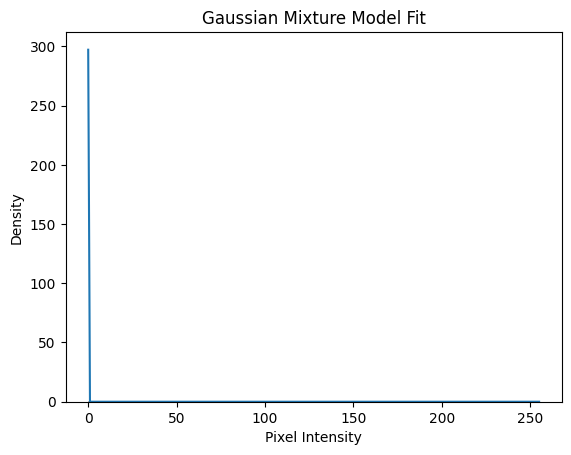

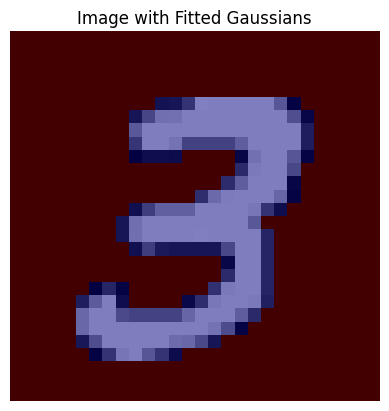

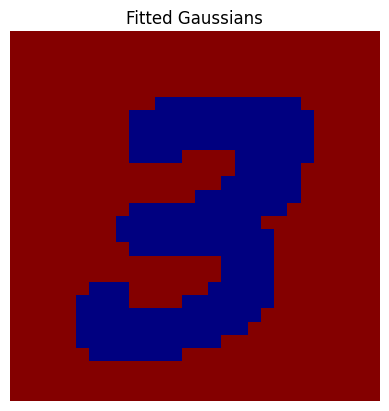

In [ ]:
def fit_gaussian_mixture_to_mnist(image, n_components=2):
    # Ensure the image is in grayscale
    if len(image.shape) == 3:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Flatten the image
    pixels = image.flatten().reshape(-1, 1)
    
    # Fit a Gaussian Mixture Model
    gmm = GaussianMixture(n_components=n_components, covariance_type='full')
    gmm.fit(pixels)
    
    return gmm

# Load the image (replace 'digit_image.png' with your image path)
image = train_images[train_labels == 3][0]

# Fit the Gaussian Mixture Model
gmm = fit_gaussian_mixture_to_mnist(image, n_components=2)

# Print the parameters of the fitted Gaussians
for i in range(gmm.n_components):
    print(f"Gaussian {i+1}:")
    print(f"  Mean: {gmm.means_[i][0]}")
    print(f"  Covariance: {gmm.covariances_[i][0][0]}")
    print(f"  Weight: {gmm.weights_[i]}")

# Visualize the fitted Gaussians
x = np.linspace(0, 255, 256)
pdf = np.exp(gmm.score_samples(x.reshape(-1, 1)))

plt.hist(image.flatten(), bins=256, density=True, alpha=0.6, color='gray')
plt.plot(x, pdf, '-')
plt.title('Gaussian Mixture Model Fit')
plt.xlabel('Pixel Intensity')
plt.ylabel('Density')
plt.show()

# Display the image with fitted Gaussians
# Generate a grid of pixel coordinates
rows, cols = image.shape
X, Y = np.meshgrid(np.arange(cols), np.arange(rows))
xy = np.column_stack([X.ravel(), Y.ravel()])

# Compute the GMM probabilities for each pixel
probs = np.exp(gmm.score_samples(image.flatten().reshape(-1, 1))).reshape(rows, cols)

# Normalize the probabilities to [0, 255] for visualization
probs = cv2.normalize(probs, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# Convert the grayscale image to a 3-channel image
image_color = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

# Overlay the GMM probabilities on the image
overlay = cv2.applyColorMap(probs, cv2.COLORMAP_JET)
overlay_image = cv2.addWeighted(image_color, 0.5, overlay, 0.5, 0)

# Display the overlay image
plt.imshow(cv2.cvtColor(overlay_image, cv2.COLOR_BGR2RGB))
plt.title('Image with Fitted Gaussians')
plt.axis('off')
plt.show()

# display only gaussians
# Display only the Gaussians
# Generate a grid of pixel coordinates
rows, cols = image.shape
X, Y = np.meshgrid(np.arange(cols), np.arange(rows))
xy = np.column_stack([X.ravel(), Y.ravel()])

# Compute the GMM probabilities for each pixel
probs = np.exp(gmm.score_samples(image.flatten().reshape(-1, 1))).reshape(rows, cols)

# Normalize the probabilities to [0, 255] for visualization
probs = cv2.normalize(probs, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# Apply a color map to the probabilities
overlay = cv2.applyColorMap(probs, cv2.COLORMAP_JET)

# Display the overlay image
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title('Fitted Gaussians')
plt.axis('off')
plt.show()